apro il file

In [51]:
import pandas as pd
dataset = "Dataset/ticket_utenti_simulati_ia.csv"
df_input = pd.read_csv(dataset)
df_input.sample(10)

,id,user_name,user_email,title,body,category,priority
114,TKT-0115,Raffaele Galli,raffaele.galli@email.it,Errore 500 in ambiente staging,Segnalazione errore: si riscontra un errore 50...,Tecnico,Alta
126,TKT-0127,Ezio Amato,ezio.amato@email.it,Picco traffico anomalo database,Urgente: il database di produzione è completam...,Tecnico,Alta
99,TKT-0100,Pino Grasso,pino.grasso@email.it,Ripristinare backup notturno staging,"Ciao, serve ripristinare il backup notturno su...",Tecnico,Media
52,TKT-0053,Lucia Ragusa,lucia.ragusa@email.it,Nota di credito mancante,"Ciao, non trovo nel portale la nota di credito...",Amministrazione,Bassa
76,TKT-0077,Simonetta De Luca,simonetta.deluca@email.it,Verificare estratto conto aziendale,"Salve, dobbiamo verificare l'estratto conto az...",Amministrazione,Bassa
57,TKT-0058,Massimo Belmonte,massimo.belmonte@email.it,Crash dell'app su desktop,Segnalazione: molti utenti riscontrano il cras...,Tecnico,Alta
87,TKT-0088,Dario Moretti,dario.moretti@email.it,Database lento in fase caricamento,"Ciao Supporto, il caricamento dei dati è blocc...",Tecnico,Media
146,TKT-0147,Giacomo Marchetti,giacomo.marchetti@email.it,Listino prezzi opzione multilicenza,"Gentile ufficio vendite, chiedo il listino pre...",Commerciale,Bassa
25,TKT-0026,Ester de Luca,ester.deluca@email.it,Giustificativo di spesa rifiutato,"Buongiorno, il sistema mi ha rifiutato il gius...",Amministrazione,Media
121,TKT-0122,Adelaide Ricci,adelaide.ricci@email.it,Sospendere estratto conto errato,"Buongiorno, chiedo di sospendere temporaneamen...",Amministrazione,Alta


controllo che non ci siano cose NaN

In [52]:
df = df_input.dropna(subset=['title','category', 'priority','body'])

preprocessing tel testo, ovvero pulizia base del testo (minuscole, rimozione punteggiatura), tokenizzazione.

In [53]:
import re
import pandas as pd

def clean_text(text):
    
    text = str(text).lower()
    
    # ^\w\s significa "tutto ciò che NON è una lettera/numero (\w) o uno spazio (\s)"
    text = re.sub(r'[^\w\s]', '', text)
    
    # rimuove spazi in generale
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


In [54]:
#Esempio di pulizia del testo prendendo un record a caso

test_record = df.sample(n=1)

print("--- RECORD REALE ESTRATTO ---")
print(test_record[['title','category', 'priority','body']])

print("\n--- RISULTATO DOPO LA PULIZIA ---")
clean_record = test_record[['title', 'category', 'priority','body']].map(clean_text)
print(clean_record)

--- RECORD REALE ESTRATTO ---
                                 title     category priority  \
101  Proposta partnership contrattuale  Commerciale    Bassa   

                                                  body  
101  Salve, vi ho inviato la nostra proposta di par...  

--- RISULTATO DOPO LA PULIZIA ---
                                 title     category priority  \
101  proposta partnership contrattuale  commerciale    bassa   

                                                  body  
101  salve vi ho inviato la nostra proposta di part...  


per questa fase, ho preso spunto dal corso di programmazione 2, in particolare nella sezione di programmazione strutturata.

In [55]:
df[['title', 'category', 'priority','body']]= df[['title', 'category', 'priority','body']].map(clean_text)

df['body_token'] = df['body'].str.split()
df.sample(10)['body_token']

10     [salve, riscontro, un, mancato, invio, dellest...
170    [salve, siamo, in, fase, di, negoziare, il, li...
42     [ciao, è, impossibile, procedere, con, i, test...
168    [ciao, dobbiamo, testare, il, ripristino, dei,...
60     [ciao, supporto, il, database, lento, causa, t...
0      [ciao, supporto, lapplicazione, va, in, crash,...
163    [gentile, contabilità, la, fattura, della, not...
39     [segnalazione, dobbiamo, isolare, la, causa, d...
64     [ciao, ho, bisogno, di, assistenza, amministra...
47     [urgente, il, nostro, account, commerciale, ri...
Name: body_token, dtype: object

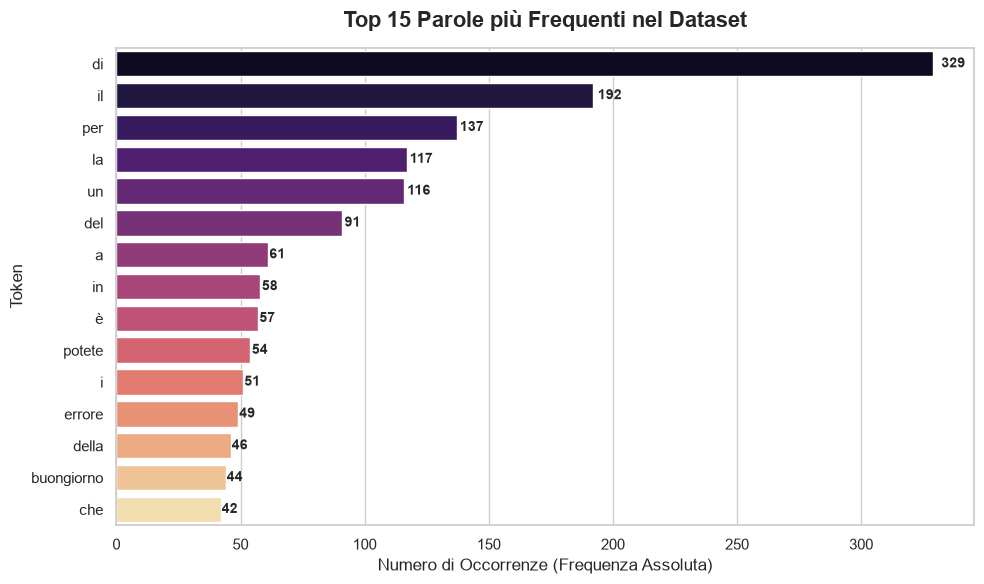

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

top_words = df['body_token'].explode().value_counts().head(15).reset_index()

top_words.columns = ['Parola', 'Frequenza']

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid") #sfondo pulito con griglia leggera

#grafico a barre orizzontali (barpot)
sns.barplot(
    x='Frequenza', 
    y='Parola', 
    data=top_words, 
    palette='magma', 
    hue='Parola',
    legend=False
)

#personalizza i testi e i titoli
plt.title('Top 15 Parole più Frequenti nel Dataset', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Numero di Occorrenze (Frequenza Assoluta)', fontsize=12)
plt.ylabel('Token', fontsize=12)

#per mettere in risalto i valori numerici alla fine di ogni barra
for index, value in enumerate(top_words['Frequenza']):
    plt.text(value + (value * 0.01), index, f'{int(value)}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

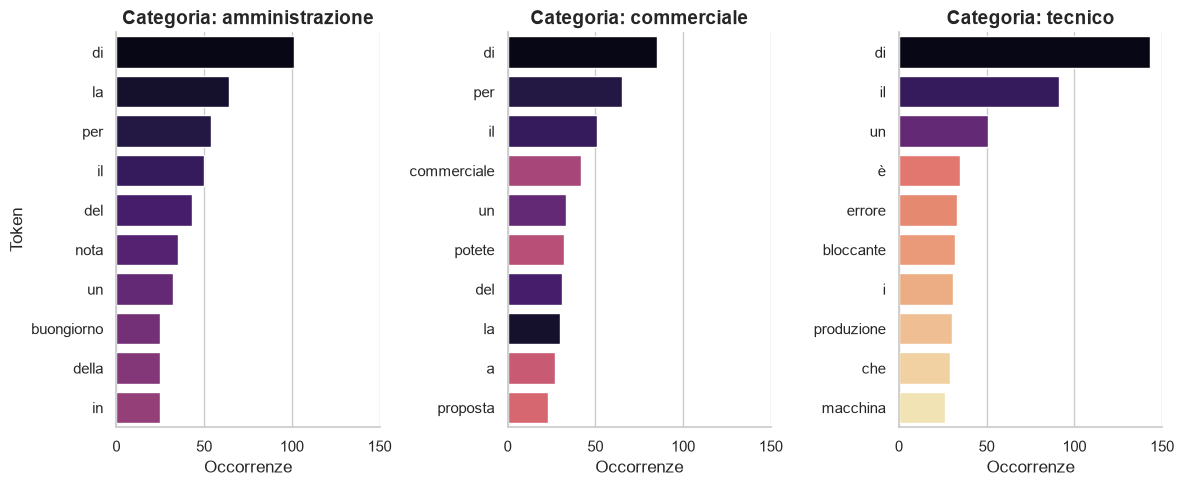

In [57]:
words_by_category = (df[['category', 'body_token']]
                     .explode('body_token')
                     .groupby(['category', 'body_token'])
                     .size()
                     .reset_index(name='Frequenza'))

#solo le top 10 parole per ogni singola categoria per non affollare il grafico
top_words_per_cat = (words_by_category
                     .sort_values(['category', 'Frequenza'], ascending=[True, False])
                     .groupby('category')
                     .head(10))

top_words_per_cat = top_words_per_cat.rename(columns={'body_token': 'Parola'})

g = sns.catplot(
    data=top_words_per_cat, 
    kind="bar",
    x="Frequenza",  
    y="Parola",
    col="category",
    palette="magma",
    hue="Parola",
    legend=False,
    sharey=False,
    height=5, 
    aspect=0.8
)

g.set_titles("Categoria: {col_name}", size=14, weight='bold')
g.set_xlabels("Occorrenze", size=12)
g.set_ylabels("Token", size=12)


plt.show()

In [63]:
df['category'].value_counts(ascending=False)

category
tecnico            67
amministrazione    67
commerciale        66
Name: count, dtype: int64

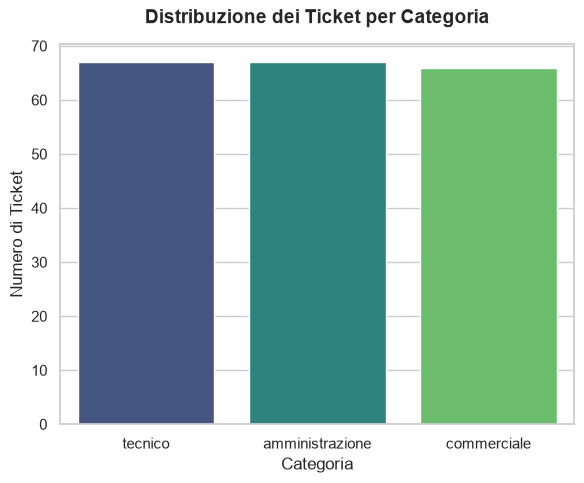

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# GRAFICO 1: Numero di ticket per ogni categoria (in ordine decrescente)

#ordine delle categorie dal valore più alto al più basso
ordine_categorie = df['category'].value_counts().index

fig1, ax1 = plt.subplots(figsize=(6, 5))
sns.countplot(
    data=df, 
    x='category', 
    order=ordine_categorie, 
    hue='category', 
    palette='viridis', 
    ax=ax1
)

#rimuovo la legenda automatica del parametro 'hue' che in questo caso è ridondante
if ax1.get_legend() is not None:
    ax1.get_legend().remove()

ax1.set_title('Distribuzione dei Ticket per Categoria', fontsize=14, pad=15, fontweight='bold')
ax1.set_xlabel('Categoria', fontsize=12)
ax1.set_ylabel('Numero di Ticket', fontsize=12)

plt.tight_layout()
plt.show()


In [61]:
df.groupby('category')['priority'].value_counts(ascending=False)

category         priority
amministrazione  bassa       29
                 media       27
                 alta        11
commerciale      bassa       47
                 media       18
                 alta         1
tecnico          alta        43
                 media       19
                 bassa        5
Name: count, dtype: int64

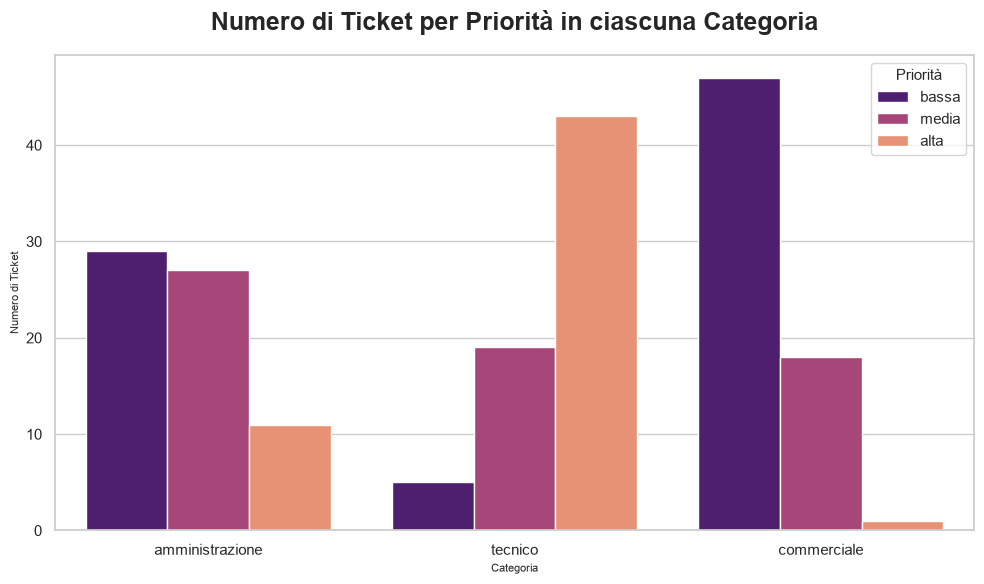

In [ ]:
fig2, ax2 = plt.subplots(figsize=(10, 6))

order = ['amministrazione', 'tecnico', 'commerciale']
sns.countplot(
    data=df, 
    x='category',
    order = order, 
    hue='priority', 
    hue_order=['bassa', 'media', 'alta'],
    palette='magma', 
    ax=ax2
)

#leggenda ed etichette varie
ax2.set_title('Numero di Ticket per Priorità in ciascuna Categoria', fontsize=18, pad=18, fontweight='bold')
ax2.set_xlabel('Categoria', fontsize=8)
ax2.set_ylabel('Numero di Ticket', fontsize=8)
ax2.legend(title='Priorità', title_fontsize='11', loc='upper right')


plt.tight_layout()
plt.show()

intanto invertire i grafici con la pulizia dell'input. comunque scrivere che già con la tokenizzation non è male, ma si potrebbe fare altra roba come lemming e simili, ma che per il momento procederò così per vedere i risultati iniziali e fare poi un confronto e rimuovendo le stop word